# Cassini CDA Dust Analyzer: Ablation Study (Incremental Batch Mode)

This notebook runs the ablation study in an **incremental, loop-based batch prediction mode**. 

Instead of consolidating all few-shot levels ($k$) into a single massive 18 GB file, this workflow processes each $k$-shot evaluation sequentially: 
1. Generates a small request JSONL file for a single $k$.
2. Uploads the file to GCS (showing a real-time progress bar).
3. Submits the batch prediction job and polls until completion.
4. Downloads the predictions and saves them in a separate Parquet file (`ablation_results_incremental/results_k{k}.parquet`).
5. Plots and saves the confusion matrix with the accuracy displayed as the title.

In [1]:
import os
import sys
import asyncio
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from google import genai
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("google_genai").setLevel(logging.WARNING)

# Ensure we can import from the workspace
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import importlib
import scripts.run_ablation_study_incremental
importlib.reload(scripts.run_ablation_study_incremental)

from scripts.run_ablation_study_incremental import (
    preprocess_huggingface_data,
    get_or_create_train_sclks,
    generate_explanations_pool,
    create_k_shot_batch_input_file,
    submit_and_poll_batch_job,
    download_and_parse_k_results,
    plot_and_save_k_results
)

from cda_dust_agent.config import Config

# Load environment variables and configurations
load_dotenv(dotenv_path="../.env")
configs = Config()
client = genai.Client()
model_id = configs.agent_settings.model

print(f"Using Model: {model_id}")

Using Model: gemini-3.5-flash


In [2]:
# 1. Fetch and Preprocess Data
print("Loading data...")
full_df = preprocess_huggingface_data("H")
print(f"Total available rows: {len(full_df)}")

# Display the class distribution to check preprocessing
print("\nClass counts:")
print(full_df['class'].value_counts())

Loading data...
Total available rows: 6986

Class counts:
class
Noise    4442
1        1183
2         829
3         246
4         210
5          42
5-Na       34
Name: count, dtype: int64


In [3]:
# 2. Split Data: Define or load reproducible training SCLKs
# Samples up to 32 (or 16) training rows per class once, and saves them to cda_dust_agent/data/ablation_study/train_sclks.json
train_sclks = get_or_create_train_sclks(full_df)

Loading existing training SCLKs from cda_dust_agent/data/ablation_study/train_sclks.json...


In [4]:
# 3. Pre-generate VLM Explanations Pool for Training SCLKs
# Explanations are generated concurrently online without specifying DPI
explanations_pool = await generate_explanations_pool(client, model_id, full_df, train_sclks)

Pre-rendering and caching training spectrum images...
Generating explanations for 152 training samples concurrently with dynamic contrastive references...
Successfully generated 152 reference explanations.


In [5]:
# 4. Prepare Test Data: Exclude training SCLKs and sample up to 100 per class
all_train_sclks_list = []
for cls, sclks in train_sclks.items():
    all_train_sclks_list.extend(sclks)
test_pool = full_df[~full_df['sclk'].isin(all_train_sclks_list)].copy()

TEST_SIZE_PER_CLASS = 100
test_dfs = []
for cls, group in test_pool.groupby('class'):
    n_samples = min(TEST_SIZE_PER_CLASS, len(group))
    if n_samples > 0:
        test_dfs.append(group.sample(n=n_samples, random_state=42))
        print(f"Included class '{cls}' in test set with {n_samples} samples.")
    else:
        print(f"Skipping class '{cls}': no remaining samples.")
        
test_df = pd.concat(test_dfs, ignore_index=True)
print(f"Test Set Size: {len(test_df)} (up to {TEST_SIZE_PER_CLASS} per class)")

Included class '1' in test set with 100 samples.
Included class '2' in test set with 100 samples.
Included class '3' in test set with 100 samples.
Included class '4' in test set with 100 samples.
Included class '5' in test set with 26 samples.
Included class '5-Na' in test set with 18 samples.
Included class 'Noise' in test set with 100 samples.
Test Set Size: 544 (up to 100 per class)



NOW WORKING ON k=1 SHOT BATCH PROCESS
Generated JSONL file with 544 requests at ablation_results_incremental/requests_k1.jsonl
Uploading ablation_results_incremental/requests_k1.jsonl to GCS bucket: turansgenaibb


Uploading GCS (k=1): 100%|██████████| 198M/198M [00:38<00:00, 5.17MB/s] 

Uploaded to gs://turansgenaibb/input/requests_k1.jsonl
Submitting Batch Job for k=1 to Vertex AI...
Job Submitted! Name: projects/355771430623/locations/global/batchPredictionJobs/552024656131915776
Polling job status every 30 seconds...
[20:46:49] Job State (k=1): JOB_STATE_PENDING


Uploading GCS (k=1): 100%|██████████| 198M/198M [00:50<00:00, 5.17MB/s]

[20:47:20] Job State (k=1): JOB_STATE_PENDING
[20:47:51] Job State (k=1): JOB_STATE_QUEUED
[20:48:23] Job State (k=1): JOB_STATE_QUEUED
[20:48:55] Job State (k=1): JOB_STATE_RUNNING
[20:49:26] Job State (k=1): JOB_STATE_RUNNING
[20:49:58] Job State (k=1): JOB_STATE_RUNNING
[20:50:29] Job State (k=1): JOB_STATE_RUNNING
[20:51:01] Job State (k=1): JOB_STATE_RUNNING


...

Uploading GCS (k=24): 100%|██████████| 3.76G/3.76G [12:46<00:00, 4.12MB/s]

[21:05:59] Job State (k=24): JOB_STATE_PENDING
[21:06:31] Job State (k=24): JOB_STATE_PENDING
[21:07:02] Job State (k=24): JOB_STATE_PENDING
[21:07:34] Job State (k=24): JOB_STATE_PENDING
[21:08:06] Job State (k=24): JOB_STATE_PENDING
[21:08:38] Job State (k=24): JOB_STATE_PENDING
[21:09:09] Job State (k=24): JOB_STATE_PENDING
[21:09:41] Job State (k=24): JOB_STATE_PENDING
[21:10:12] Job State (k=24): JOB_STATE_PENDING
[21:10:44] Job State (k=24): JOB_STATE_PENDING
[21:11:15] Job State (k=24): JOB_STATE_PENDING
[21:11:46] Job State (k=24): JOB_STATE_PENDING
[21:12:18] Job State (k=24): JOB_STATE_PENDING
[21:12:49] Job State (k=24): JOB_STATE_QUEUED
[21:13:21] Job State (k=24): JOB_STATE_RUNNING
[21:13:53] Job State (k=24): JOB_STATE_RUNNING
[21:14:24] Job State (k=24): JOB_STATE_RUNNING
[21:14:55] Job State (k=24): JOB_STATE_RUNNING
[21:15:27] Job State (k=24): JOB_STATE_RUNNING
[21:15:58] Job State (k=24): JOB_STATE_RUNNING
[21:16:30] Job State (k=24): JOB_STATE_RUNNING
[21:17:02] Job

Uploading GCS (k=24): 100%|██████████| 3.76G/3.76G [1:12:07<00:00, 868kB/s]

[22:04:57] Job State (k=24): JOB_STATE_SUCCEEDED
Job for k=24 Completed Successfully!


Saved results to ablation_results_incremental/results_k24.parquet
k=24-shot learning: Accuracy = 83.09%
Saved confusion matrix plot to ablation_results_incremental/confusion_matrix_k24.png


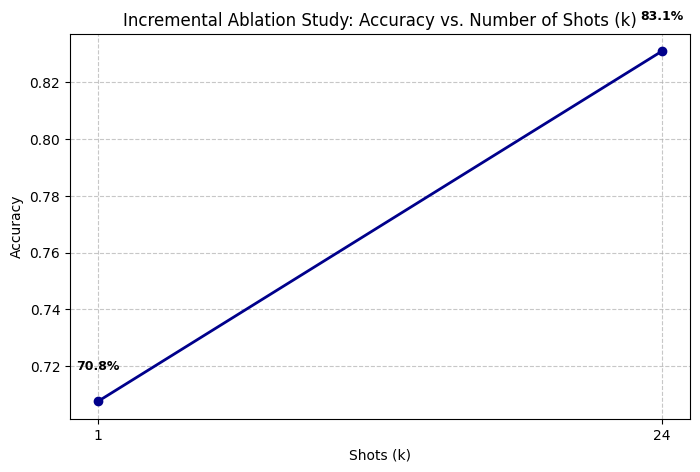


Final accuracy curve saved to ablation_results_incremental/accuracy_vs_k.png


In [6]:
# 5. Run Incremental Ablation Study Loop
# Each loop iteration executes an independent batch prediction job on Vertex AI
k_values = [1, 2, 4, 8, 12, 16, 24, 32, 48, 96, 128]
k_values = [1, 24]

results_dir = "ablation_results_incremental"
os.makedirs(results_dir, exist_ok=True)

import matplotlib.pyplot as plt

accuracies = []
for k in k_values:
    print(f"\n{'='*50}\nNOW WORKING ON k={k} SHOT BATCH PROCESS\n{'='*50}")
    
    # a. Create requests JSONL
    local_jsonl = f"{results_dir}/requests_k{k}.jsonl"
    create_k_shot_batch_input_file(test_df, explanations_pool, k, local_jsonl)
    
    # b. Upload, submit job and poll
    job_status = submit_and_poll_batch_job(configs, local_jsonl, k)
    
    # c. Download and parse results
    output_parquet = f"{results_dir}/results_k{k}.parquet"
    k_results_df = download_and_parse_k_results(configs, job_status, test_df, output_parquet, k)
    
    # d. Generate metrics and plot CM
    acc = plot_and_save_k_results(k_results_df, results_dir, k)
    accuracies.append(acc)
    
# e. Plot final accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linewidth=2, color='darkblue')
for x, y in zip(k_values, accuracies):
    plt.text(x, y + 0.01, f"{y:.1%}", ha='center', va='bottom', fontsize=9, fontweight='semibold')
plt.title("Incremental Ablation Study: Accuracy vs. Number of Shots (k)")
plt.xlabel("Shots (k)")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_values)

curve_path = os.path.join(results_dir, "accuracy_vs_k.png")
plt.savefig(curve_path)
plt.show()
print(f"\nFinal accuracy curve saved to {curve_path}")

k=1-shot learning: Loaded 544 samples, Accuracy = 70.77%
k=24-shot learning: Loaded 544 samples, Accuracy = 83.09%


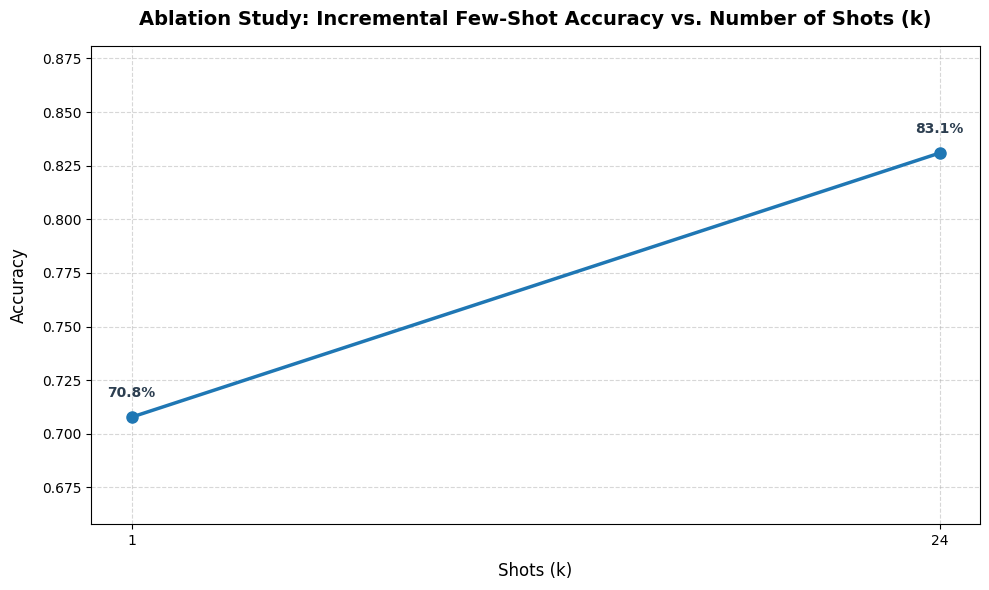


Final local accuracy curve plotted and saved to ablation_results_incremental/accuracy_vs_k_local.png


In [7]:
# 6. Read Local Results and Plot Accuracy vs. Shots (k)
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

k_values = [1, 2, 4, 8, 12, 16, 24, 32, 48, 96]
k_values = [1, 24]

results_dir = "ablation_results_incremental"
accuracies = []
loaded_k = []

for k in k_values:
    parquet_path = os.path.join(results_dir, f"results_k{k}.parquet")
    if os.path.exists(parquet_path):
        results_df = pd.read_parquet(parquet_path)
        # Exclude predictions with 'error' if any
        sub_df = results_df[results_df['predicted_label'] != 'error']
        if len(sub_df) > 0:
            acc = accuracy_score(sub_df['true_label'], sub_df['predicted_label'])
            accuracies.append(acc)
            loaded_k.append(k)
            print(f"k={k}-shot learning: Loaded {len(sub_df)} samples, Accuracy = {acc:.2%}")
        else:
            print(f"k={k}-shot learning: No valid predictions in {parquet_path}")
    else:
        print(f"k={k}-shot learning: Result file {parquet_path} not found.")

if accuracies:
    # Plot final accuracy curve with rich aesthetics
    plt.figure(figsize=(10, 6))
    plt.plot(loaded_k, accuracies, marker='o', markersize=8, linewidth=2.5, color='#1f77b4', label='Accuracy')
    
    # Add labels on the points
    for x, y in zip(loaded_k, accuracies):
        plt.text(x, y + 0.008, f"{y:.1%}", ha='center', va='bottom', fontsize=10, fontweight='semibold', color='#2c3e50')
        
    plt.title("Ablation Study: Incremental Few-Shot Accuracy vs. Number of Shots (k)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Shots (k)", fontsize=12, labelpad=10)
    plt.ylabel("Accuracy", fontsize=12, labelpad=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(loaded_k)
    plt.ylim(min(accuracies) - 0.05, max(accuracies) + 0.05)
    plt.tight_layout()
    
    curve_path = os.path.join(results_dir, "accuracy_vs_k_local.png")
    plt.savefig(curve_path, dpi=300)
    plt.show()
    print(f"\nFinal local accuracy curve plotted and saved to {curve_path}")
else:
    print("No result files found to plot.")